# Low-reliability clean/incorrect activation patching

**Historical exact-question audit:** the user subsequently clarified that questions
and observed answers may differ when agreement totals or grids match. That active
follow-up is in [notebook 20](20_noisy_channel_agreement_matched_patching.ipynb).
The zero-pair result below applies to the earlier constraints, not the clarified task.

This notebook follows notebook 18's completed reasoning-off probes. The screen is
promising for diagnosing a missing reliability-sign interaction: the reliability
sign is available while the signed product is weak at the prompt boundary. It does
not yet identify a reliable signed-posterior direction for a behavioral repair.

The requested experiment matches **the same reliability, exact question sets,
answer pattern, candidate ordering, candidate identities, and reasoning off**.
Clean means a correct emitted answer on a non-tie Bayesian comparison; corrupted
means an incorrect emitted answer. Boundary-logit correctness is reported separately.
Noisy versus clean describes behavior here, not a deliberately corrupted prompt.

The exact match is checked before loading any model. CUDA is hidden in this notebook.
The original training kernel and artifacts are read-only inputs.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
import json
import sys
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'pyproject.toml').exists())
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))
from completed_probe_exploration import match_audit, behavior_frame, write_json, write_jsonl
from patching_exploration import layerwise_margin_decomposition, make_reliability_design, prospective_matching_audit, summarize_offloaded_interchange
MODEL_ROOT = REPO_ROOT/'artifacts/noisy_channel_bayesian_experiment_2_activation_patching/Qwen_Qwen3.5-9B_4c87a623'
ANALYSIS_ROOT = MODEL_ROOT/'analyses/completed_reasoning_off_20260905'
OUTPUT_ROOT = ANALYSIS_ROOT/'low_reliability_patching'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_ROOT = MODEL_ROOT/'runs/qwen35_9b_n9_k3_r10_s64_selected_tokens_v2_reasoning_off'
results = [json.loads(line) for line in (RUN_ROOT/'results.jsonl').read_text().splitlines() if line.strip()]
assert len(results) == 5120 and all(r['reasoning'] is False for r in results)
snapshot = json.loads((ANALYSIS_ROOT/'snapshot.json').read_text())


## Reproduce the user selections and audit the exact matching condition

There is one deterministic generation per prompt. Repeating a prompt with sampled
answer numerals would not create different residual states at its prompt boundary:
those states occur before sampling. Patching a token that already contains the
answer would instead risk copying the answer itself.

In [2]:
audit = match_audit(results, OUTPUT_ROOT)
display(pd.DataFrame([audit]).T)
frame = behavior_frame(results)
for label, mask in [
    ('high-r incorrect C2', (frame.reliability > .5) & (frame.delta_a > 0) & (frame.emitted_choice == 'C2')),
    ('low-r correct C1', (frame.reliability < .5) & (frame.delta_a < 0) & (frame.emitted_choice == 'C1')),
]:
    selected = frame[mask]
    display(Markdown(f'### {label}: {len(selected)} rows'))
    display(selected.groupby('reliability').agg(rows=('row_id', 'size'),
              emitted_accuracy=('emitted_correct', 'mean'),
              boundary_logit_accuracy=('logit_correct', 'mean'),
              distinct_schedules=('schedule', 'nunique')))
    selected.to_csv(OUTPUT_ROOT/(label.replace(' ', '_') + '.csv'), index=False)


,0
matching_fields,"[reliabilities_exact, membership_sets, observe..."
low_reliability_non_tie_rows,1680
unique_exact_conditions,1680
repeated_exact_conditions,0
exact_clean_corrupt_groups,0
exact_directed_clean_to_corrupt_pairs,0
high_reliability_c2_audit_count,335
low_reliability_c1_audit_count,41
low_c1_emitted_correct_but_nonpositive_margin,7
conclusion,No exact matched clean/incorrect donors exist ...


### high-r incorrect C2: 335 rows

,rows,emitted_accuracy,boundary_logit_accuracy,distinct_schedules
reliability,,,,
0.55,74,0.0,0.0,36
0.65,74,0.0,0.0,34
0.75,68,0.0,0.0,30
0.85,62,0.0,0.0,29
0.95,57,0.0,0.0,28


### low-r correct C1: 41 rows

,rows,emitted_accuracy,boundary_logit_accuracy,distinct_schedules
reliability,,,,
0.05,9,1.0,0.666667,7
0.15,11,1.0,0.636364,9
0.25,7,1.0,1.000000,6
0.35,7,1.0,1.000000,6
0.45,7,1.0,1.000000,6


In [3]:
MATCH_FIELDS = ('reliabilities_exact', 'membership_sets', 'observed_reports',
                'presentation_order', 'candidate_1', 'candidate_2', 'reasoning')
groups = defaultdict(list)
for row in results:
    if row['reliabilities'][0] < .5 and row['delta_a'] != 0:
        groups[json.dumps([row[field] for field in MATCH_FIELDS], sort_keys=True)].append(row)
directions = []
for group in groups.values():
    clean = [row for row in group if row['canonical_posterior_correct']]
    corrupted = [row for row in group if not row['canonical_posterior_correct']]
    for good in clean:
        for bad in corrupted:
            for donor, recipient, direction in [(good, bad, 'denoising'), (bad, good, 'noising')]:
                directions.append({'donor_row_id': donor['row_id'], 'recipient_row_id': recipient['row_id'],
                                   'direction': direction, 'matching_fields': list(MATCH_FIELDS)})
write_jsonl(OUTPUT_ROOT/'exact_patch_directions.jsonl', directions)
display({'exact_directed_patches': len(directions), 'status': 'no_eligible_pairs' if not directions else 'ready'})
if not directions:
    display(Markdown('**No exact matched donor/recipient pair exists.** The saved bank cannot answer whether\nthat intervention fixes behavior. The empty result is a data-design limitation, not\na negative causal result. Changing exact question sets while holding both candidates’\nper-question agreement patterns fixed is one possible alternative; it changes the\nquestion-matching constraint and is not executed here without that choice.'))


{'exact_directed_patches': 0, 'status': 'no_eligible_pairs'}

**No exact matched donor/recipient pair exists.** The saved bank cannot answer whether
that intervention fixes behavior. The empty result is a data-design limitation, not
a negative causal result. Changing exact question sets while holding both candidates’
per-question agreement patterns fixed is one possible alternative; it changes the
question-matching constraint and is not executed here without that choice.

## Eligibility under the pending alternative matching choice

This is a count-only audit of a possible alternative, not a change to the requested
experiment. It allows different exact question sets while holding each candidate's
entire per-question agreement pattern fixed, along with reliability, observed reports,
answer ordering, identities, and reasoning off. The Bayesian comparison stays identical.
No donor is selected and no relaxed-match intervention is run.

Counts distinguish emitted-answer correctness from the stricter requirement that the
emitted answer and a non-tied boundary-logit choice agree. They are broken out by
train/test split and Bayesian winner. Reusing rows in many pairs does not create
independent observations.

In [4]:
prospective_counts = prospective_matching_audit(results, OUTPUT_ROOT)
display(prospective_counts)


,split,correctness_criterion,bayes_winner,mixed_groups,denoising_pairs_if_relaxed,noising_pairs_if_relaxed,unique_clean_rows,unique_corrupted_rows,executed
0,all,emitted_answer,C1,11,18,18,16,13,False
1,all,emitted_answer,C2,57,71,71,69,59,False
2,all,emitted_answer,both,68,89,89,85,72,False
3,all,emitted_and_strict_boundary_agree,C1,8,13,13,13,8,False
4,all,emitted_and_strict_boundary_agree,C2,28,32,32,32,28,False
5,all,emitted_and_strict_boundary_agree,both,36,45,45,45,36,False
6,train,emitted_answer,C1,7,14,14,12,9,False
7,train,emitted_answer,C2,48,61,61,59,50,False
8,train,emitted_answer,both,55,75,75,71,59,False
9,train,emitted_and_strict_boundary_agree,C1,5,10,10,10,5,False


## Experiment 2: even and odd agreement slopes across depth

For each symmetric reliability pair, decode C1−C2 with the model's own final
normalization and answer-token weights applied to the saved residual at each layer.
Plot the slope of `(m_low + m_high)/2` (even) and `(m_high − m_low)/2` (odd)
on agreement difference. These are descriptive logit-lens readouts; intermediate
layers are not calibrated output distributions and do not prove causal use.

We compare `final_prompt` (before assistant output) with `answer_prefix` (immediately
before the answer numeral). Neither includes the answer numeral. Uncertainty is a
bootstrap over the eight held-out schedules, keeping report patterns and reliability
pairs together. The head-only final-layer check is verified against saved logits.

Saved-state CPU logit-lens readout 160 / 640


Saved-state CPU logit-lens readout 320 / 640


Saved-state CPU logit-lens readout 480 / 640


Saved-state CPU logit-lens readout 640 / 640


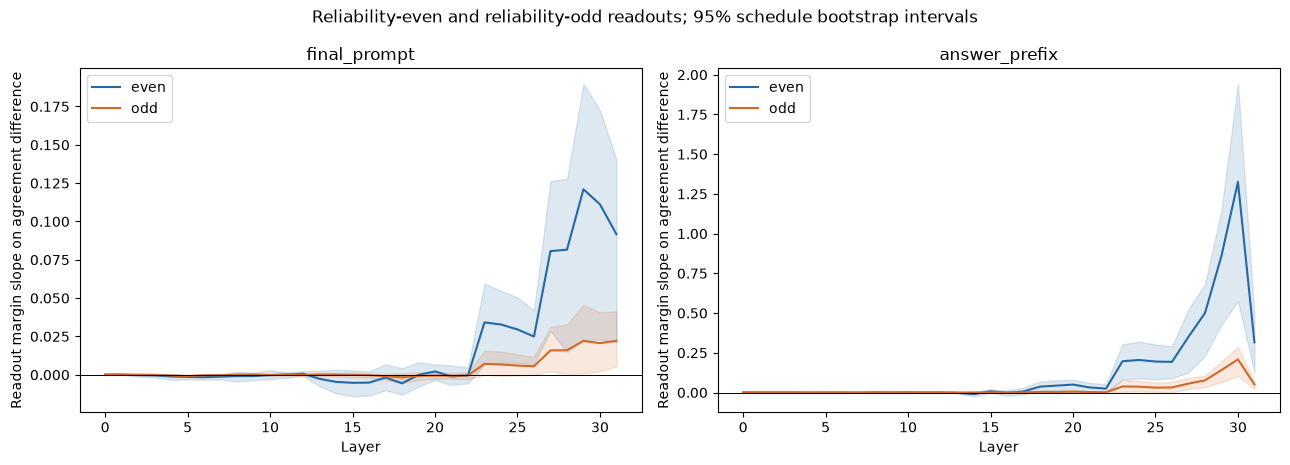

{'rows': 640,
 'only_final_norm_and_two_head_rows_loaded': True,
 'max_absolute_difference': 0.125,
 'mean_absolute_difference': 0.0001953125,
 'within_original_0_05_tolerance_fraction': 0.9984375,
 'interpretation': 'Head-only reconstruction verifies saved final residual readout; it does not validate CPU full-model replay.'}

,site,layer,component,slope,ci_low,ci_high,schedule_count,bootstrap_samples,aggregation,readout
0,final_prompt,0,even,0.000117,-0.000126,0.000290,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
1,final_prompt,0,odd,-0.000029,-0.000104,0.000044,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
14,final_prompt,7,even,-0.001247,-0.003050,0.000187,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
15,final_prompt,7,odd,-0.000292,-0.000980,0.000436,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
30,final_prompt,15,even,-0.005258,-0.014082,0.002851,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
31,final_prompt,15,odd,-0.000104,-0.001731,0.001459,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
46,final_prompt,23,even,0.034140,0.006902,0.059505,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
47,final_prompt,23,odd,0.007109,-0.000287,0.015608,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
62,final_prompt,31,even,0.091638,0.021102,0.140329,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...
63,final_prompt,31,odd,0.022139,0.005539,0.041357,8,2000,pooled across all five symmetric reliability p...,final norm and head in float32 on saved BF16 r...


In [5]:
decomposition, head_parity = layerwise_margin_decomposition(
    results, RUN_ROOT, REPO_ROOT/'models/Qwen--Qwen3.5-9B', OUTPUT_ROOT)
display(head_parity)
display(decomposition[decomposition.layer.isin([0, 7, 15, 23, 31])])


## Original notebook-16 reliability interchange: a separate experiment

This keeps question sets, report pattern, candidates and ordering fixed, and swaps
reliability between 0.05/0.95 or 0.25/0.75. It changes reliability, so it does not
answer the same-reliability clean/incorrect follow-up above. The 64 directed pairs
and three `final_prompt` layers are selected from the saved design and training CV.
Exact posterior ties are retained as continuous controls and excluded from choice
accuracy. The immutable design is saved before any patched forward pass.

The CPU compatibility check uses the same local checkpoint in float32 and compares
unpatched margins against the saved BF16 capture with notebook 16's 0.05 tolerance.
A failed gate prevents claims about patching the saved GPU behavior. The original
screen includes unpatched/self-patch checks, both directions, and raw margin changes.
Stronger causal claims additionally require mean/resampled and off-target controls.
Whole-residual patches are not evidence for a specific low-dimensional sign mechanism.

In [6]:
reliability_design = make_reliability_design(results, snapshot, OUTPUT_ROOT)
display({key: value for key, value in reliability_design.items() if key != 'directions'})
parity_path = ANALYSIS_ROOT/'cpu_patch_parity.json'
cpu_parity = json.loads(parity_path.read_text()) if parity_path.exists() else {'complete': False, 'status': 'not_run'}
display(cpu_parity)
bf16_path = ANALYSIS_ROOT/'cpu_patch_parity_bf16_linear_fp32_accumulation.json'
bf16_parity = json.loads(bf16_path.read_text()) if bf16_path.exists() else {'complete': False}
display(bf16_parity)
full_capture_path = ANALYSIS_ROOT/'cpu_patch_parity_bf16_linear_fp32_accumulation_full_capture_forward.json'
full_capture_parity = json.loads(full_capture_path.read_text()) if full_capture_path.exists() else {'complete': False}
display(full_capture_parity)
write_json(OUTPUT_ROOT/'status.json', {
    'exact_followup_status': 'no_eligible_pairs' if not directions else 'ready',
    'exact_pair_count': len(directions),
    'reliability_interchange_design_directions': len(reliability_design['directions']),
    'cpu_parity_complete': cpu_parity.get('complete', False),
    'cpu_compatible': cpu_parity.get('compatible', False),
    'cpu_bf16_compatible': bf16_parity.get('compatible', False),
    'cpu_full_capture_replay_complete': full_capture_parity.get('complete', False),
    'cpu_full_capture_compatible': full_capture_parity.get('compatible', False),
    'gpu_used': False,
    'causal_rescue_measured': False,
})


{'experiment': 'notebook16_reliability_interchange_separate_from_exact_followup',
 'site': 'final_prompt',
 'layers': [2, 31, 29],
 'layer_selection': 'training grouped CV only, frozen before test access',
 'row_count': 64,
 'non_tie_directions': 56,
 'reasoning': False,
 'gpu_used': False,
 'controls': ['unpatched',
  'self_patch',
  'resampled_donor_same_reliability',
  'training_mean_same_reliability',
  'off_target_domain_boundary'],
 'probe_config_fingerprint': '94deb694dd14359ba2547f1bed3c7d80ed5c54111c9d8e081f557be0ef274f55',
 'design_sha256': 'a36b8af3588263449b49626227600d75a3aaa8b1ac4a47b8e5eebf3a9a895848'}

{'device': 'cpu',
 'dtype': 'float32',
 'saved_capture_dtype': 'bfloat16',
 'tolerance_from_notebook16': 0.05,
 'records': [{'row_id': '47f89f048506582277f19c76',
   'reliability': '1/20',
   'cpu_margin': -0.44823265075683594,
   'saved_margin': -0.5,
   'absolute_difference': 0.05176734924316406,
   'seconds': 22.860861403867602},
  {'row_id': '5b2ad9b4d2b0c9091d39e718',
   'reliability': '19/20',
   'cpu_margin': 0.4062633514404297,
   'saved_margin': 0.375,
   'absolute_difference': 0.03126335144042969,
   'seconds': 22.803017265163362},
  {'row_id': '7de3591a1f3137350ac38670',
   'reliability': '1/4',
   'cpu_margin': -0.2006855010986328,
   'saved_margin': -0.25,
   'absolute_difference': 0.04931449890136719,
   'seconds': 25.65394234377891},
  {'row_id': '624aace20f7a58781c6055da',
   'reliability': '3/4',
   'cpu_margin': 0.4174385070800781,
   'saved_margin': 0.375,
   'absolute_difference': 0.042438507080078125,
   'seconds': 26.838153939694166}],
 'complete': True,
 'compati

{'device': 'cpu',
 'dtype': 'bf16_linear_fp32_accumulation',
 'saved_capture_dtype': 'bfloat16',
 'tolerance_from_notebook16': 0.05,
 'records': [{'row_id': '47f89f048506582277f19c76',
   'reliability': '1/20',
   'cpu_logits': [22.375, 22.875],
   'cpu_margin': -0.5,
   'saved_margin': -0.5,
   'absolute_difference': 0.0,
   'seconds': 25.60543802473694},
  {'row_id': '5b2ad9b4d2b0c9091d39e718',
   'reliability': '19/20',
   'cpu_logits': [23.0, 22.625],
   'cpu_margin': 0.375,
   'saved_margin': 0.375,
   'absolute_difference': 0.0,
   'seconds': 25.945695389062166},
  {'row_id': '7de3591a1f3137350ac38670',
   'reliability': '1/4',
   'cpu_logits': [22.75, 22.875],
   'cpu_margin': -0.125,
   'saved_margin': -0.25,
   'absolute_difference': 0.125,
   'seconds': 28.912096607498825},
  {'row_id': '624aace20f7a58781c6055da',
   'reliability': '3/4',
   'cpu_logits': [23.125, 22.625],
   'cpu_margin': 0.5,
   'saved_margin': 0.375,
   'absolute_difference': 0.125,
   'seconds': 22.691927

{'device': 'cpu',
 'dtype': 'bf16_linear_fp32_accumulation',
 'saved_capture_dtype': 'bfloat16',
 'replays_full_capture_forward': True,
 'scored_position': 'answer_boundary_input_index',
 'tolerance_from_notebook16': 0.05,
 'records': [{'row_id': '47f89f048506582277f19c76',
   'reliability': '1/20',
   'cpu_logits': [22.375, 22.875],
   'cpu_margin': -0.5,
   'saved_margin': -0.5,
   'absolute_difference': 0.0,
   'seconds': 29.33817285299301},
  {'row_id': '5b2ad9b4d2b0c9091d39e718',
   'reliability': '19/20',
   'cpu_logits': [23.0, 22.625],
   'cpu_margin': 0.375,
   'saved_margin': 0.375,
   'absolute_difference': 0.0,
   'seconds': 32.67628409713507},
  {'row_id': '7de3591a1f3137350ac38670',
   'reliability': '1/4',
   'cpu_logits': [22.75, 22.875],
   'cpu_margin': -0.125,
   'saved_margin': -0.25,
   'absolute_difference': 0.125,
   'seconds': 32.64194836560637},
  {'row_id': '624aace20f7a58781c6055da',
   'reliability': '3/4',
   'cpu_logits': [23.125, 22.75],
   'cpu_margin': 

## Optional full-resident runner (unused)

The offloaded run in the next section has completed this screen; there is no need
to repeat it. This alternative checks live GPU compute processes before importing torch or loading
a model. It never contacts or interrupts an existing kernel. Set the execution flag
only to request a run once the GPU is unoccupied; an occupied GPU always prevents it.
The runner reuses notebook 16's actual patching code, fixed to reasoning off, with
the snapshot's CV-selected layers and a separate output directory. Its original
unpatched-margin compatibility gate still applies.

This is notebook 16's whole-residual screen. It does **not** yet contain all the
mean/resampled/off-target controls required for experiment 2's stronger causal claim,
and it does not implement the nonexistent exact same-reliability pair design.

In [7]:
import subprocess
RUN_ORIGINAL_INTERCHANGE = False
command = [str(REPO_ROOT/'.venv/bin/python'), str(REPO_ROOT/'scripts/run_completed_probe_patching.py')]
if RUN_ORIGINAL_INTERCHANGE:
    command.append('--execute-gpu')
check = subprocess.run(command, capture_output=True, text=True, check=False)
print(check.stdout)
if check.returncode:
    print(check.stderr)
assert check.returncode == 0
patch_path = ANALYSIS_ROOT/'original_reliability_interchange_gpu/results.jsonl'
if patch_path.exists():
    patch_rows = [json.loads(line) for line in patch_path.read_text().splitlines() if line.strip()]
    display(pd.DataFrame(patch_rows))
else:
    print('The optional full-resident runner has not been used. See the offloaded results below.')


{"status": "waiting_for_unoccupied_gpu", "compute_processes": ["273484, 642", "326499, 18568"], "executed": false, "existing_kernels_contacted": false}

The optional full-resident runner has not been used. See the offloaded results below.


## Native GPU replay with weights offloaded to CPU

The live fits were verified to be scikit-learn CPU jobs while the GPU had unused
compute and over 12 GiB of memory free. A separate native-BF16 GPU process transfers
weights module by module from CPU and caps its allocator at 6 GiB. It never changes
the live kernel or its allocation. The four original compatibility strata are
checked before patching, and every recipient gets a fresh baseline and saved-state
self-patches at the three locked layers.

This section reads saved outputs; it does not launch GPU work from this CPU notebook.
All records preserve exact questions/reports/ordering and change reliability. We
report accuracy against both the recipient's original Bayesian answer and the donor's
counterfactual answer, so a changed target is never mislabeled as a same-task repair.
An unfinished run is labeled partial, and no exact same-reliability repair claim is made.

The locked layers are 2, 29, and 31. A final-prompt patch after layer 31 has no
remaining layer in which to influence the later answer-prefix position; its null
effect is structurally expected under this teacher-forced scoring design. That
control must not be interpreted as evidence against a reliability representation.
Only answer-boundary logits are measured here; patched completions are not regenerated.

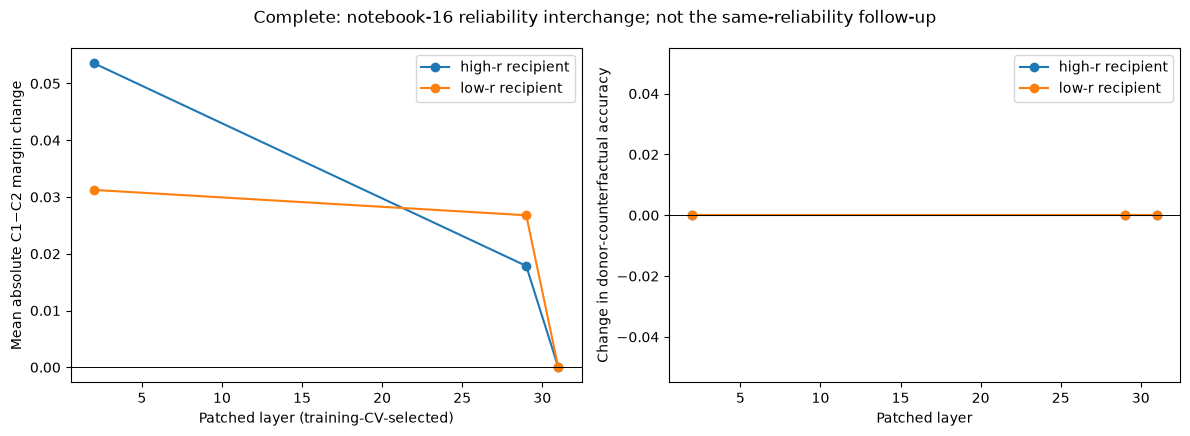

{'status': {'complete': True,
  'records': 384,
  'interchange_records': 192,
  'self_patch_records': 192,
  'peak_allocated_mib': 2202.81982421875,
  'peak_reserved_mib': 2234.0,
  'after': {'total_mib': 32607,
   'free_mib': 10025,
   'utilization_percent': 67,
   'owners': {'273484': 642, '326499': 18568, '411454': 2856}},
  'existing_processes_modified': False},
 'setup': {'cpu_offload': True,
  'dtype': 'bfloat16',
  'cuda_allocator_limit_mib': 6144,
  'before': {'total_mib': 32607,
   'free_mib': 12887,
   'utilization_percent': 0,
   'owners': {'273484': 642, '326499': 18568}},
  'existing_processes_modified': False,
  'capture_replay': 'full saved sequence; score at answer_boundary_input_index',
  'design_sha256': 'a36b8af3588263449b49626227600d75a3aaa8b1ac4a47b8e5eebf3a9a895848',
  'pid': 411454},
 'compatibility': {'records': [{'row_id': '47f89f048506582277f19c76',
    'reliability': '1/20',
    'saved_margin': -0.5,
    'replayed_margin': -0.5,
    'absolute_difference': 0.0

,layer,recipient_reliability_regime,directed_pairs,schedules,baseline_original_task_accuracy,patched_original_task_accuracy,baseline_donor_counterfactual_accuracy,patched_donor_counterfactual_accuracy,mean_raw_margin_change,mean_absolute_margin_change,max_absolute_margin_change,choice_changes,original_task_repairs,original_task_harms,mean_change_toward_donor_counterfactual,run_complete
0,2,high,28,7,0.785714,0.785714,0.107143,0.107143,-0.026786,0.053571,0.125,0,0,0,-0.017857,True
1,2,low,28,7,0.285714,0.285714,0.642857,0.642857,-0.004464,0.031250,0.125,0,0,0,0.004464,True
2,29,high,28,7,0.785714,0.785714,0.107143,0.107143,0.000000,0.017857,0.125,0,0,0,0.000000,True
3,29,low,28,7,0.285714,0.285714,0.642857,0.642857,0.008929,0.026786,0.125,0,0,0,0.000000,True
4,31,high,28,7,0.785714,0.785714,0.107143,0.107143,0.000000,0.000000,0.000,0,0,0,0.000000,True
5,31,low,28,7,0.285714,0.285714,0.642857,0.642857,0.000000,0.000000,0.000,0,0,0,0.000000,True


**Completed:** 192 reliability-interchange patches and 192 self-patches. Non-tie margin-sign changes: 0; original-task repairs: 0; newly incorrect choices: 0. This is a result for the reliability-changing whole-residual screen, not the requested same-reliability clean/incorrect intervention. That follow-up remains unmeasured because no exact matched pairs exist.

In [8]:
offloaded_audit, offloaded_summary = summarize_offloaded_interchange(ANALYSIS_ROOT, OUTPUT_ROOT)
display(offloaded_audit)
display(offloaded_summary)
if offloaded_audit['status'].get('complete'):
    display(Markdown(
        f"**Completed:** {offloaded_audit['interchange_records']} reliability-interchange patches "
        f"and {offloaded_audit['self_patch_records']} self-patches. "
        f"Non-tie margin-sign changes: {offloaded_audit['non_tie_choice_changes']}; "
        f"original-task repairs: {offloaded_audit['non_tie_original_task_repairs']}; "
        f"newly incorrect choices: {offloaded_audit['non_tie_original_task_harms']}. "
        "This is a result for the reliability-changing whole-residual screen, "
        "not the requested same-reliability clean/incorrect intervention. "
        "That follow-up remains unmeasured because no exact matched pairs exist."))
